In [13]:
import pandas as pd
import os

# Full Table

In [14]:
results_dir = "/hdd/ivny/results"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

methods_names = {
    "dist_linguistic_confidence": "Ling. Conf.",
    "dist_semantic_uncertainty": "Semantic Unc.",
    "dist_lnll": "Token Prob."
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "trivia_qa": "TriviaQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

all_records = []
for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, estimation_method, _, model_name, _ = leaf_dir.split("/")
    csv_data = pd.read_csv(os.path.join(leaf_dir, "eval_metrics.csv")).to_dict(orient="records")[0]
    df_dict = {
        "Dataset": dataset_map[dataset_name],
        "Est. Method": methods_names[estimation_method],
        "Model": model_name_map[model_name],
        **csv_data
    }
    all_records.append(df_dict)

full_results_df = pd.DataFrame(all_records).round(3)
full_results_df.rename(columns={"accuracy": "Acc", "generalised_ece": r"ECE$_{gen}$", "dECE_point_mass": r"ECE$_{pm}$", "AUROC_point_mass": r"AUROC$_{pm}$"}, inplace=True)
full_results_df

,Dataset,Est. Method,Model,Acc,ECE$_{gen}$,dECE,ECE$_{pm}$,dAUROC,AUROC$_{pm}$
0,MMLU,Ling. Conf.,Llama-3.1-8B-Inst.,0.626,0.124,0.126,0.093,0.609,0.645
1,MMLU,Ling. Conf.,Llama-3-8B-Inst.,0.619,0.190,0.191,0.166,0.557,0.583
2,MMLU,Ling. Conf.,Qwen2.5-7B-Inst.,0.672,0.142,0.145,0.069,0.566,0.592
3,MMLU,Ling. Conf.,Qwen3-8B-Inst.,0.749,0.146,0.147,0.062,0.562,0.595
4,MMLU,Ling. Conf.,Mistral-7B-Inst.,0.566,0.277,0.277,0.213,0.526,0.529
5,MMLU,Ling. Conf.,GPT-OSS-20B,0.774,0.157,0.160,0.073,0.562,0.576
6,MMLU,Semantic Unc.,Llama-3.1-8B-Inst.,0.609,0.234,0.272,0.227,0.729,0.728
7,MMLU,Semantic Unc.,Llama-3-8B-Inst.,0.595,0.254,0.264,0.249,0.709,0.708
8,MMLU,Semantic Unc.,Qwen2.5-7B-Inst.,0.708,0.273,0.302,0.272,0.547,0.547
9,MMLU,Semantic Unc.,Qwen3-8B-Inst.,0.693,0.271,0.303,0.270,0.586,0.586


# Average Aggregated Table

In [15]:
# Aggregate
latex_output = (
    full_results_df
    .drop(columns=["Dataset", "Acc"])
    .groupby(["Est. Method", "Model"])
    .mean()
    .round(3)
    .to_latex(
        multirow=True,
        float_format="%.3f",
        escape=False,
        column_format="l p{2.8cm} rrrrr"  # <-- THIS controls wrapping
    )
)

print(latex_output)

\begin{tabular}{l p{2.8cm} rrrrr}
\toprule
 &  & ECE$_{gen}$ & dECE & ECE$_{pm}$ & dAUROC & AUROC$_{pm}$ \\
Est. Method & Model &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{Ling. Conf.} & GPT-OSS-20B & 0.255 & 0.256 & 0.222 & 0.617 & 0.648 \\
 & Llama-3-8B-Inst. & 0.198 & 0.199 & 0.170 & 0.578 & 0.606 \\
 & Llama-3.1-8B-Inst. & 0.144 & 0.146 & 0.125 & 0.659 & 0.695 \\
 & Mistral-7B-Inst. & 0.276 & 0.277 & 0.249 & 0.564 & 0.604 \\
 & Qwen2.5-7B-Inst. & 0.184 & 0.186 & 0.155 & 0.605 & 0.642 \\
 & Qwen3-8B-Inst. & 0.239 & 0.239 & 0.207 & 0.565 & 0.620 \\
\cline{1-7}
\multirow[t]{6}{*}{Semantic Unc.} & GPT-OSS-20B & 0.207 & 0.251 & 0.197 & 0.667 & 0.668 \\
 & Llama-3-8B-Inst. & 0.262 & 0.269 & 0.252 & 0.649 & 0.652 \\
 & Llama-3.1-8B-Inst. & 0.241 & 0.262 & 0.230 & 0.662 & 0.664 \\
 & Mistral-7B-Inst. & 0.308 & 0.296 & 0.299 & 0.632 & 0.638 \\
 & Qwen2.5-7B-Inst. & 0.242 & 0.257 & 0.234 & 0.644 & 0.649 \\
 & Qwen3-8B-Inst. & 0.247 & 0.254 & 0.240 & 0.659 & 0.662 \\
\cline{1-7}
\multirow[t

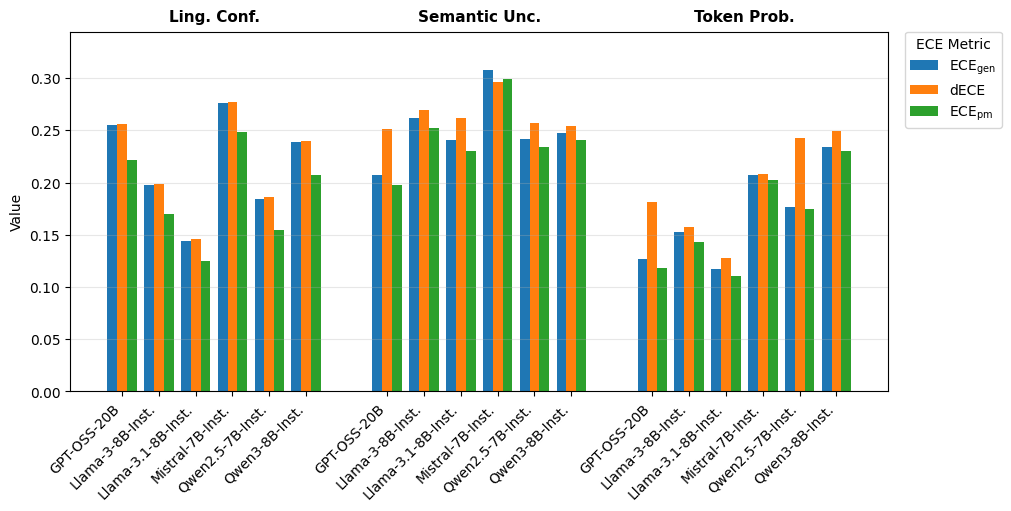

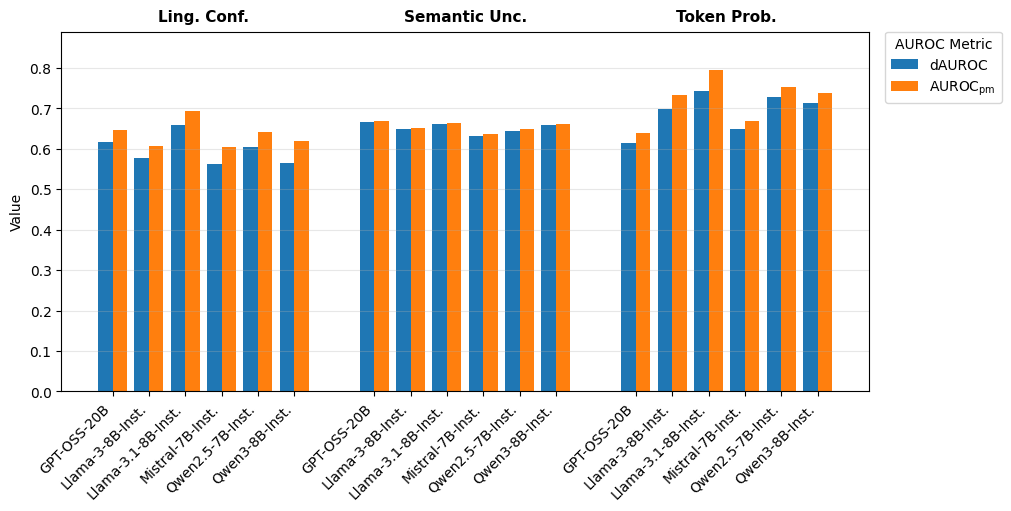

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Average across datasets so each row is (LLM, estimation method).
plot_df = (
    full_results_df
    .drop(columns=["Dataset", "Acc"], errors="ignore")
    .groupby(["Model", "Est. Method"], as_index=False)
    .mean(numeric_only=True)
)

# Support both raw metric names and renamed LaTeX-friendly names.
ece_candidates = [
    ("ECE$_{gen}$", "ECE_gen"),
    ("generalised_ece", "ECE_gen"),
    ("dECE", "dECE"),
    ("ECE$_{pm}$", "ECE_pm"),
    ("dECE_point_mass", "ECE_pm"),
]
auroc_candidates = [
    ("dAUROC", "dAUROC"),
    ("AUROC$_{pm}$", "AUROC_pm"),
    ("AUROC_point_mass", "AUROC_pm"),
]

selected = {}
for col, label in ece_candidates + auroc_candidates:
    if col in plot_df.columns and label not in selected:
        selected[label] = col

ece_order = ["ECE_gen", "dECE", "ECE_pm"]
auroc_order = ["dAUROC", "AUROC_pm"]

# Display labels for legend entries.
display_metric_labels = {
    "ECE_gen": r"ECE$_{\mathrm{gen}}$",
    "ECE_pm": r"ECE$_{\mathrm{pm}}$",
    "AUROC_pm": r"AUROC$_{\mathrm{pm}}$",
}

missing = [m for m in (ece_order + auroc_order) if m not in selected]
if missing:
    raise ValueError(
        f"Missing required metrics: {missing}. Available columns: {list(plot_df.columns)}"
    )

method_order_pref = ["Ling. Conf.", "Semantic Unc.", "Token Prob."]
method_order = [m for m in method_order_pref if m in plot_df["Est. Method"].unique()]
method_order += sorted([m for m in plot_df["Est. Method"].unique() if m not in method_order])
model_order = sorted(plot_df["Model"].unique())


def build_ordered_metric_df(metric_order):
    rows = []
    for method in method_order:
        for model in model_order:
            match = plot_df[(plot_df["Est. Method"] == method) & (plot_df["Model"] == model)]
            if not match.empty:
                record = {"Est. Method": method, "Model": model}
                for metric in metric_order:
                    record[metric] = match.iloc[0][selected[metric]]
                rows.append(record)
    return pd.DataFrame(rows)


def grouped_bar_by_method(metric_df, metric_order, title, legend_title, filename, figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    group_gap = 1.2
    n_metrics = len(metric_order)
    bar_width = 0.8 / n_metrics

    x_positions = []
    x_labels = []
    group_centers = []
    group_boundaries = []

    x_cursor = 0.0
    for method in method_order:
        group_rows = metric_df[metric_df["Est. Method"] == method]
        if group_rows.empty:
            continue

        start_x = x_cursor
        for _, row in group_rows.iterrows():
            x_positions.append(x_cursor)
            x_labels.append(row["Model"])
            x_cursor += 1.0

        end_x = x_cursor - 1.0
        group_centers.append(((start_x + end_x) / 2.0, method))
        group_boundaries.append(end_x + group_gap / 2.0)
        x_cursor += group_gap

    x = np.array(x_positions)

    for i, metric in enumerate(metric_order):
        offset = (i - (n_metrics - 1) / 2) * bar_width
        values = metric_df[metric].to_numpy()
        display_label = display_metric_labels.get(metric, metric)
        ax.bar(x + offset, values, width=bar_width, label=display_label)

    # Visual separators and method labels help make the 3 x-axis groups explicit.
    # for boundary in group_boundaries[:-1]:
    #     ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.35)

    # ax.set_title(title)
    # ax.set_xlabel("Models (grouped by estimation method)")
    ax.set_ylabel("Value")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(
        title=legend_title,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
    )

    # Force y-axis to start at 0 while keeping a tight top range.
    all_values = metric_df[metric_order].to_numpy(dtype=float).ravel()
    all_values = all_values[np.isfinite(all_values)]
    if all_values.size > 0:
        y_max = float(np.max(all_values))
        y_range_from_zero = max(y_max, 1e-6)
        pad_top = y_range_from_zero * 0.12
        ax.set_ylim(0.0, y_max + pad_top)

    for center, method in group_centers:
        ax.text(
            center,
            1.02,
            method,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    plt.savefig(filename, bbox_inches="tight", dpi=300)


ece_plot_df = build_ordered_metric_df(ece_order)
auroc_plot_df = build_ordered_metric_df(auroc_order)

grouped_bar_by_method(
    ece_plot_df,
    ece_order,
    "ECE Metrics grouped by Estimation Method",
    "ECE Metric",
    "main_eval_ece.pdf",
)

grouped_bar_by_method(
    auroc_plot_df,
    auroc_order,
    "AUROC Metrics grouped by Estimation Method",
    "AUROC Metric",
    "main_eval_auroc.pdf",
)